In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("/content/car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


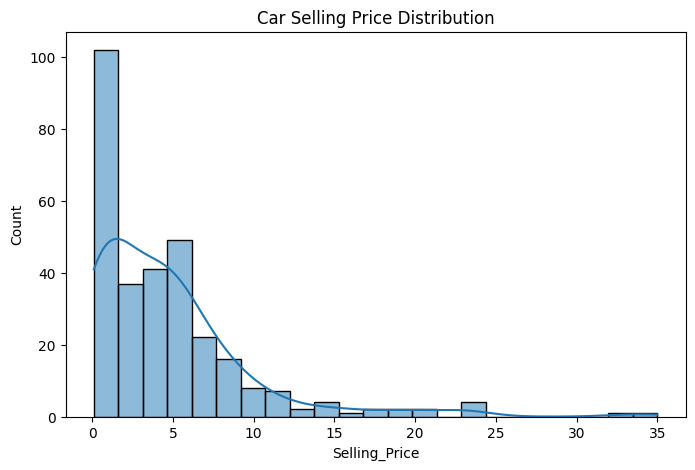

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"], kde=True)

plt.title("Car Selling Price Distribution")
plt.show()

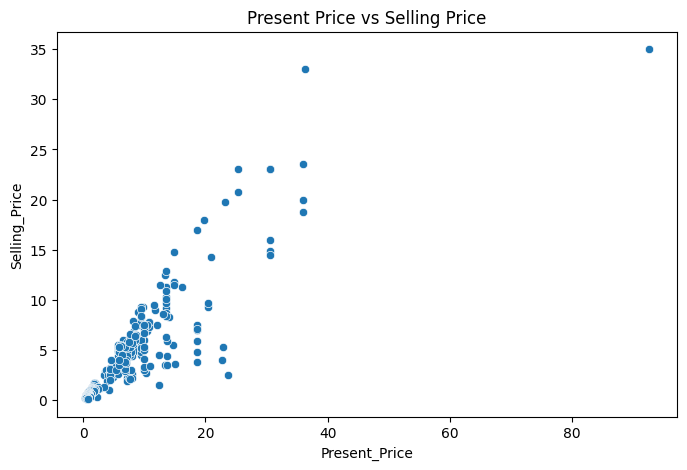

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Present_Price",
    y="Selling_Price",
    data=df
)

plt.title("Present Price vs Selling Price")
plt.show()

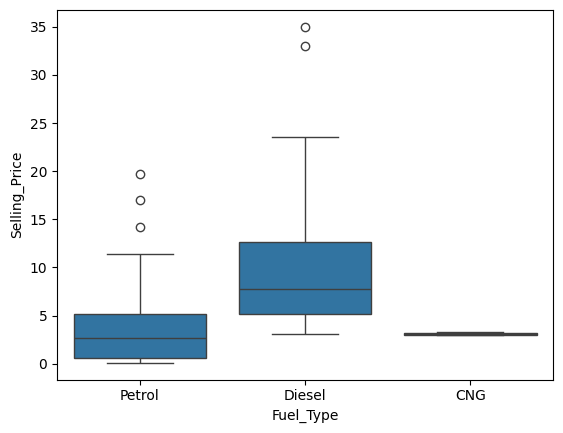

In [11]:
sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.show()

In [12]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

In [13]:
df.drop(
    ["Car_Name","Year"],
    axis=1,
    inplace=True
)

In [14]:
encoder = LabelEncoder()


df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])

df["Selling_type"] = encoder.fit_transform(df["Selling_type"])

df["Transmission"] = encoder.fit_transform(df["Transmission"])

In [15]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,12
1,4.75,9.54,43000,1,0,1,0,13
2,7.25,9.85,6900,2,0,1,0,9
3,2.85,4.15,5200,2,0,1,0,15
4,4.60,6.87,42450,1,0,1,0,12


In [16]:
X = df.drop("Selling_Price",axis=1)

y = df["Selling_Price"]

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

LinearRegression()

In [19]:
lr_pred = lr.predict(X_test)

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [21]:
rf_pred = rf.predict(X_test)

In [22]:
def evaluate(y_test,pred):

    print("MAE:",
          mean_absolute_error(y_test,pred))

    print("RMSE:",
          np.sqrt(mean_squared_error(y_test,pred)))

    print("R2 Score:",
          r2_score(y_test,pred))

In [23]:
evaluate(
    y_test,
    lr_pred
)

MAE: 1.221932362175385
RMSE: 1.8792498207978197
R2 Score: 0.8466902419663827


In [24]:
evaluate(
    y_test,
    rf_pred
)

MAE: 0.6389196721311476
RMSE: 0.9686468632776881
R2 Score: 0.9592683769360726


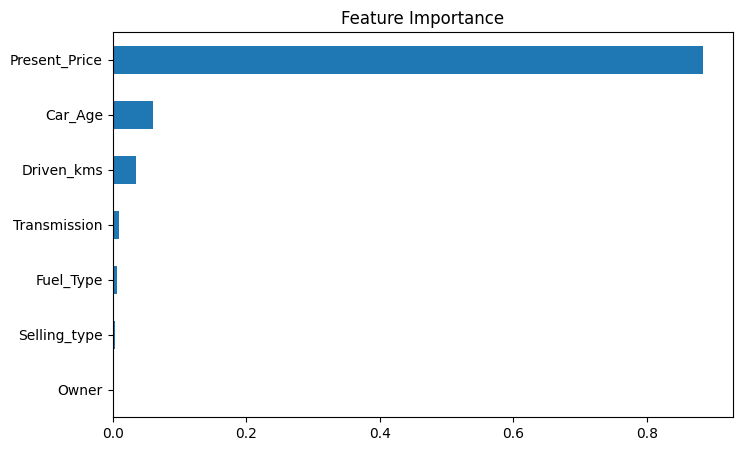

In [25]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

In [26]:
car = np.array(
[
[5.59,27000,0,0,0,1,0]
]
)


prediction = rf.predict(car)


print(
"Estimated Selling Price:",
prediction[0],
"Lakh"
)

Estimated Selling Price: 4.224000000000002 Lakh


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
new_car = pd.DataFrame({

    "Present_Price":[10],
    "Driven_kms":[30000],
    "Fuel_Type":[2],
    "Selling_type":[0],
    "Transmission":[1],
    "Owner":[0],
    "Car_Age":[3]

})


price = model.predict(new_car)


print(
"Predicted Car Price:",
round(price[0],2),
"Lakh"
)

Predicted Car Price: 7.92 Lakh
